# Trajectory Inference with StaVIA

If you use StaVIA in your research, please cite:

StaVIA: Spatio-Temporal Latent Embeddings and Vector field Inference for Collective Cell Migrations.

Paper: <https://www.biorxiv.org/content/10.1101/2024.07.04.601964v1
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        

Code: <https://github.com/ShobiStassen/VIA>

Documentation: <https://pyvia.readthedocs.io/en/latest/Atlas%20view%20examples.html>

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import anndata as ad
import omicverse as ov
from anndata import AnnData
from omicverse.external import VIA

import matplotlib.pyplot as plt
ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Load and preprocess the original tutorial data

This notebook keeps the dentate gyrus neurogenesis dataset used by the original StaVIA tutorial. The dataset contains multiple neurogenesis-related cell populations and is suitable for demonstrating branching trajectories, lineage probabilities, and gene dynamics.

In [2]:
adata = scv.datasets.dentategyrus()
adata

AnnData object with n_obs × n_vars = 2930 × 13913
    obs: 'clusters', 'age(days)', 'clusters_enlarged'
    uns: 'clusters_colors'
    obsm: 'X_umap'
    layers: 'ambiguous', 'spliced', 'unspliced'

In [3]:
adata = ov.pp.preprocess(adata, mode="shiftlog|pearson", n_HVGs=2000)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features].copy()
ov.pp.scale(adata)
ov.pp.pca(adata, layer="scaled", n_pcs=50)

🔍 [2026-05-23 03:41:47] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 13264/13913 genes are kept.
    Among 13264 genes, 13189 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 4 highly-expressed genes from normalization computation
   Excluded genes: ['Hba-a1', 'Malat1', 'Ptgds', 'Hbb-bt']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,930 cells × 13,189 genes
   ✓ Runtime: 0.05s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 13,189 total (15.2%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.60 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

   🔧 PCA solver used: covariance_eigh
    finished✅ (3.05s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 3.0553s                                                 │
│  Shape:    2,930 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 2930x50)                               │
│           │ ✚ scaled|original|X_pca (array, 2930x50)               │
│         

In [4]:
ov.pp.neighbors(
    adata,
    use_rep="scaled|original|X_pca",
    n_neighbors=15,
    n_pcs=30,
)
ov.pp.umap(adata, min_dist=1)

🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: scaled|original|X_pca
   PCs used: 30
   🔍 Computing neighbor distances...
   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 2,930 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 5.1496s                                                 │
│  Shape:    2,930 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 2,930 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.4217s                                                 │
│  Shape:    2,930 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.11497568273577367, 'b': 1.9292371475038...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


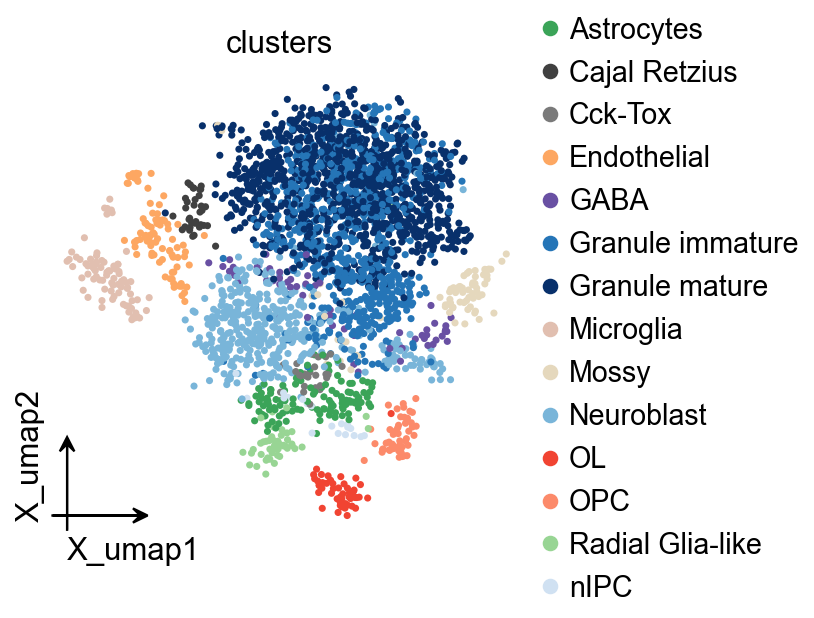

In [5]:
ov.pl.embedding(
    adata,
    basis="X_umap",
    color=["clusters"],
    frameon="small",
    cmap="Reds",
)

## Construct and run the model

In [6]:
stavia = ov.single.StaVIA(
    adata,
    use_rep="scaled|original|X_pca",
    n_comps=30,
    basis="X_umap",
    cluster_key="clusters",
    spatial_key=None,  # 空间 AnnData 可设置为 "spatial"
    time_key=None,
    sample_key=None,
    key_added="stavia",
    root="nIPC",
    knn=15,
    random_seed=4,
    memory=10,
    num_threads=1,
    n_iter_leiden=5,
    num_mcmc_simulations=200,
    edgepruning_clustering_resolution=0.15,
    cluster_graph_pruning=0.15,
    resolution_parameter=1.5,
)

stavia.fit()
v0 = stavia.model
stavia_embedding = np.asarray(adata.obsm[stavia.basis])[:, [0, 1]]


2026-05-23 03:41:58.520110	Running VIA over input data of 2930 (samples) x 30 (features)
2026-05-23 03:41:58.520196	Knngraph has 15 neighbors


2026-05-23 03:41:59.159246	Finished global pruning of 15-knn graph used for clustering at level of 0.15. Kept 43.8 % of edges. 
2026-05-23 03:41:59.164576	Number of connected components used for clustergraph  is 1
2026-05-23 03:41:59.192988	Commencing community detection
2026-05-23 03:41:59.304745	Finished community detection. Found 537 clusters.
2026-05-23 03:41:59.305380	Merging 496 very small clusters (<10)
2026-05-23 03:41:59.307873	Finished detecting communities. Found 41 communities
2026-05-23 03:41:59.307983	Making cluster graph. Global cluster graph pruning level: 0.15
2026-05-23 03:41:59.310461	Graph has 1 connected components before pruning
2026-05-23 03:41:59.311200	Graph has 14 connected components after pruning
2026-05-23 03:41:59.313895	Graph has 1 connected components after reconnecting
2026-05-23 03:41:59.314115	0.0% links trimmed from local pruning relative to start
2026-05-23 03:41:59.314129	55.5% links trimmed from global pruning relative to start
initial links 346 a

2026-05-23 03:42:03.031378	Ended all multiprocesses, will retrieve and reshape
2026-05-23 03:42:03.046939	start computing walks with rw2 method


  0%|          | 0/1300 [00:00<?, ?it/s]

memory for rw2 hittings times  2. Using rw2 based pt
2026-05-23 03:42:06.215805	Identifying terminal clusters corresponding to unique lineages...
2026-05-23 03:42:06.215825	Closeness:[8, 10, 11, 15, 16, 19, 20, 21, 25, 28, 31, 36, 38, 40]
2026-05-23 03:42:06.215832	Betweenness:[2, 4, 5, 6, 7, 8, 10, 11, 12, 14, 15, 16, 17, 19, 20, 22, 25, 26, 28, 29, 30, 31, 33, 34, 36, 38, 39]
2026-05-23 03:42:06.215837	Out Degree:[4, 5, 7, 8, 10, 11, 14, 15, 16, 17, 20, 21, 24, 25, 26, 28, 29, 30, 31, 34, 36, 38, 40]
2026-05-23 03:42:06.215999	Terminal clusters corresponding to unique lineages in this component are [34, 4, 5, 36, 7, 8, 38, 11, 14, 19, 25, 26, 28, 29, 30, 31] 
2026-05-23 03:42:06.216009	Calculating lineage probability at memory 10


...

2026-05-23 03:42:08.064817	Cluster or terminal cell fate 14 is reached 471.0 times
2026-05-23 03:42:08.094192	19 cluster/state is never reached. try increase number of KNN (which will increase number of edges) or try to increase the value of jac_std_global and cluster_graph_pruning which will lower edge pruning
2026-05-23 03:42:08.122250	Cluster or terminal cell fate 25 is reached 41.0 times
2026-05-23 03:42:08.150453	Cluster or terminal cell fate 26 is reached 43.0 times
2026-05-23 03:42:08.179153	Cluster or terminal cell fate 28 is reached 1.0 times
2026-05-23 03:42:08.195867	Cluster or terminal cell fate 29 is reached 763.0 times
2026-05-23 03:42:08.223063	Cluster or terminal cell fate 30 is reached 178.0 times
2026-05-23 03:42:08.250671	Cluster or terminal cell fate 31 is reached 42.0 times
2026-05-23 03:42:08.256473	There are (16) terminal clusters corresponding to unique lineages {34: 'Granule immature', 4: 'Granule immature', 5: 'Granule mature', 36: 'Endothelial', 7: 'Granule i

2026-05-23 03:42:08.553971	Cluster graph layout based on forward biasing
2026-05-23 03:42:08.555818	Starting make edgebundle viagraph...


2026-05-23 03:42:10.624382	Make via clustergraph edgebundle
2026-05-23 03:42:10.784876	Hammer dims: Nodes shape: (41, 2) Edges shape: (154, 3)
2026-05-23 03:42:10.785206	Graph has 1 connected components before pruning
2026-05-23 03:42:10.785870	Graph has 17 connected components after pruning
2026-05-23 03:42:10.789041	Graph has 1 connected components after reconnecting
2026-05-23 03:42:10.789217	51.3% links trimmed from local pruning relative to start
2026-05-23 03:42:10.789229	54.5% links trimmed from global pruning relative to start
initial links 154 and final_links_n 75
2026-05-23 03:42:10.790419	Start making edgebundle milestone with 150 milestones...This can be recomputed with make_edgebundle_milestone()
2026-05-23 03:42:10.790443	Start finding milestones


2026-05-23 03:42:11.179825	End milestones with 150
2026-05-23 03:42:11.179901	Will use via-pseudotime for edges, otherwise consider providing a list of numeric labels (single cell level) or via_object
2026-05-23 03:42:11.182473	Recompute weights
2026-05-23 03:42:11.194560	pruning milestone graph based on recomputed weights
2026-05-23 03:42:11.195179	Graph has 1 connected components before pruning
2026-05-23 03:42:11.195457	Graph has 4 connected components after pruning
2026-05-23 03:42:11.196548	Graph has 1 connected components after reconnecting
2026-05-23 03:42:11.197007	66.4% links trimmed from global pruning relative to start
2026-05-23 03:42:11.197023	regenerate igraph on pruned edges
2026-05-23 03:42:11.200202	Setting numeric label as single cell pseudotime for coloring edges
2026-05-23 03:42:11.205151	Making smooth edges


REMEMBER TO RE-INCLUDE the PLT.SHOW HERE - COMMENTING IT OUT FOR NOW
2026-05-23 03:42:11.523012	Time elapsed 12.7 seconds


## StaVIA graph structure and pseudotime

tune edges False


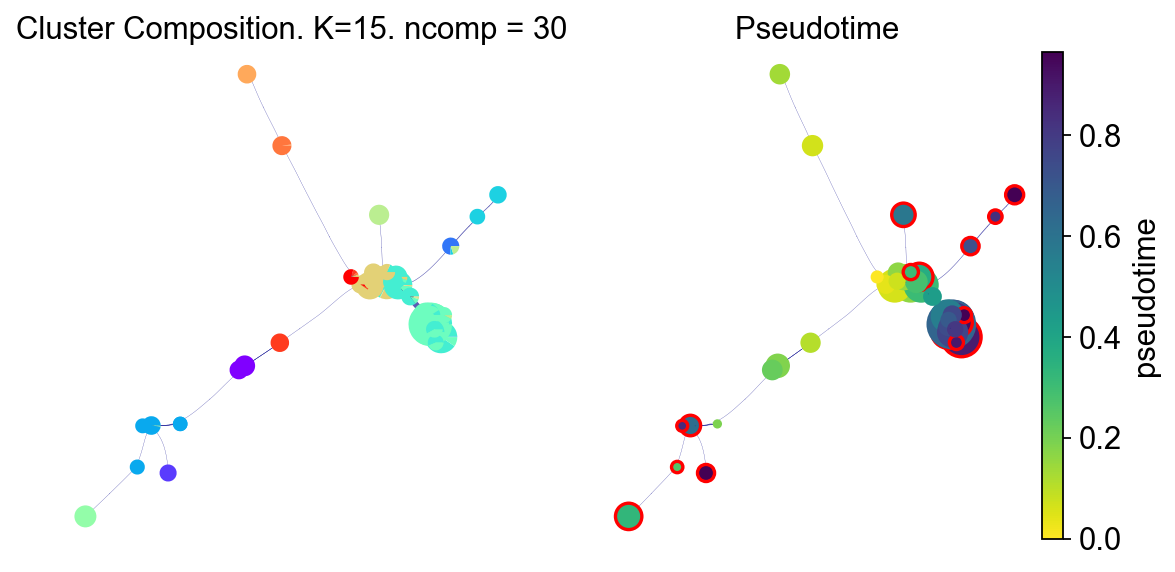

In [7]:
fig, ax, ax1 = VIA.core.plot_piechart_viagraph(
    via_object=v0,
    dpi=80,
    ax_text=False,
    show_legend=False,
)
fig.set_size_inches(8, 4)
plt.show()


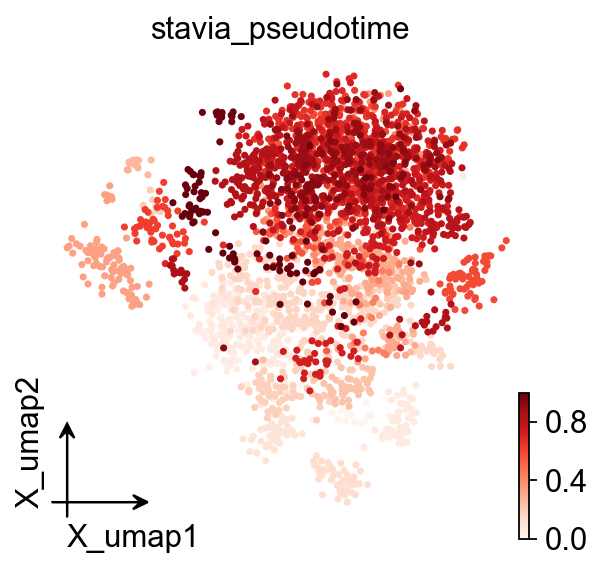

In [8]:
ov.pl.embedding(
    adata,
    basis="X_umap",
    color=[stavia.pseudotime_key],
    frameon="small",
    cmap="Reds",
)

## StaVIA trajectory projection

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00

 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

...

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00

 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

2026-05-23 03:42:18.522921	Super cluster 4 is a super terminal with sub_terminal cluster 34
2026-05-23 03:42:18.524379	Super cluster 5 is a super terminal with sub_terminal cluster 4
2026-05-23 03:42:18.524405	Super cluster 7 is a super terminal with sub_terminal cluster 5
2026-05-23 03:42:18.524421	Super cluster 8 is a super terminal with sub_terminal cluster 36
2026-05-23 03:42:18.524438	Super cluster 11 is a super terminal with sub_terminal cluster 7
2026-05-23 03:42:18.524454	Super cluster 14 is a super terminal with sub_terminal cluster 8
2026-05-23 03:42:18.524484	Super cluster 19 is a super terminal with sub_terminal cluster 38
2026-05-23 03:42:18.524506	Super cluster 25 is a super terminal with sub_terminal cluster 11
2026-05-23 03:42:18.524522	Super cluster 26 is a super terminal with sub_terminal cluster 14
2026-05-23 03:42:18.524538	Super cluster 28 is a super terminal with sub_terminal cluster 19
2026-05-23 03:42:18.524557	Super cluster 29 is a super terminal with sub_termi

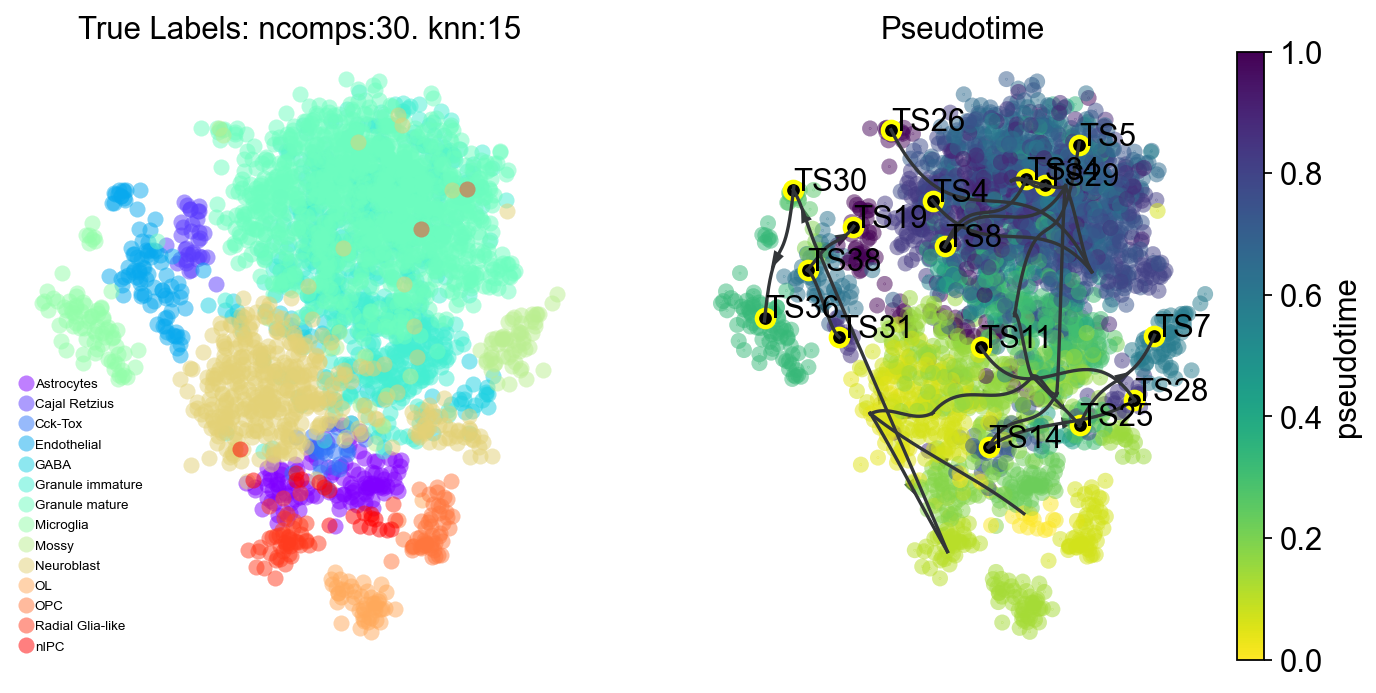

In [9]:
fig, ax, ax1 = VIA.core.plot_trajectory_curves(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=80,
    draw_all_curves=False,
)
fig.set_size_inches(10, 5)
plt.show()


## StaVIA lineage probabilities

Following the probabilistic pathways section in `t_via.ipynb`, we first show all terminal lineage probabilities and then inspect the first two terminal lineages separately.

2026-05-23 03:42:18.907709	Marker_lineages: [34, 4, 5, 36, 7, 8, 38, 11, 14, 19, 25, 26, 28, 29, 30, 31]
2026-05-23 03:42:18.908332	The number of components in the original full graph is 1
2026-05-23 03:42:18.908346	For downstream visualization purposes we are also constructing a low knn-graph 


2026-05-23 03:42:22.112467	Check sc pb 1.0000000000000002 
f getting majority comp
2026-05-23 03:42:22.136347	Cluster path on clustergraph starting from Root Cluster 33 to Terminal Cluster 34: [33, 23, 27, 9, 1, 3, 24, 18, 37, 6, 34]
2026-05-23 03:42:22.136364	Cluster path on clustergraph starting from Root Cluster 33 to Terminal Cluster 4: [33, 23, 27, 9, 1, 3, 24, 18, 37, 6, 22, 4]
2026-05-23 03:42:22.136371	Cluster path on clustergraph starting from Root Cluster 33 to Terminal Cluster 5: [33, 23, 27, 9, 1, 3, 24, 18, 37, 0, 5]
2026-05-23 03:42:22.136377	Cluster path on clustergraph starting from Root Cluster 33 to Terminal Cluster 36: [33, 23, 21, 40, 36]
2026-05-23 03:42:22.136383	Cluster path on clustergraph starting from Root Cluster 33 to Terminal Cluster 7: [33, 23, 27, 9, 1, 3, 7]
2026-05-23 03:42:22.136388	Cluster path on clustergraph starting from Root Cluster 33 to Terminal Cluster 8: [33, 23, 21, 40, 36, 8]
2026-05-23 03:42:22.136394	Cluster path on clustergraph starting f

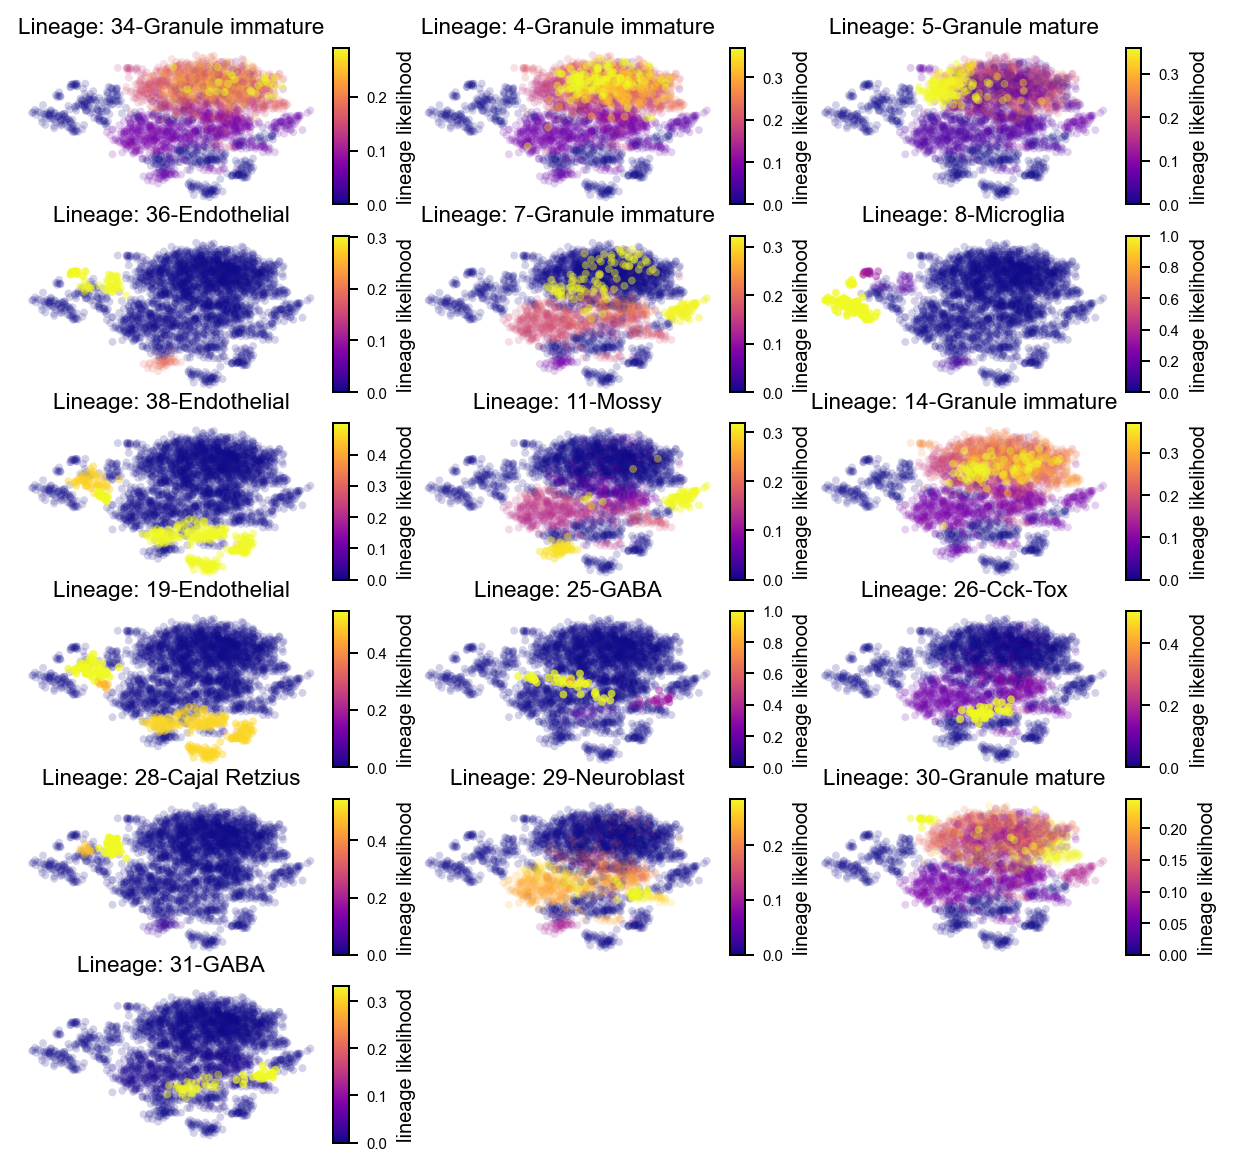

In [10]:
fig, axs = VIA.core.plot_sc_lineage_probability(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=90,
)
fig.set_size_inches(8, 8)
plt.show()


2026-05-23 03:42:22.768337	Marker_lineages: [34, 4]
2026-05-23 03:42:22.768924	The number of components in the original full graph is 1
2026-05-23 03:42:22.768935	For downstream visualization purposes we are also constructing a low knn-graph 


2026-05-23 03:42:25.981370	Check sc pb 1.0000000000000002 
f getting majority comp
2026-05-23 03:42:26.004326	Cluster path on clustergraph starting from Root Cluster 33 to Terminal Cluster 34: [33, 23, 27, 9, 1, 3, 24, 18, 37, 6, 34]
2026-05-23 03:42:26.004345	Cluster path on clustergraph starting from Root Cluster 33 to Terminal Cluster 4: [33, 23, 27, 9, 1, 3, 24, 18, 37, 6, 22, 4]
setting vmin to 0.0
2026-05-23 03:42:26.015852	Revised Cluster level path on sc-knnGraph from Root Cluster 33 to Terminal Cluster 34 along path: [16, 16, 10, 21, 40, 18, 14, 14, 14]
setting vmin to 0.0
2026-05-23 03:42:26.022199	Revised Cluster level path on sc-knnGraph from Root Cluster 33 to Terminal Cluster 4 along path: [16, 16, 10, 21, 40, 18, 4, 4]


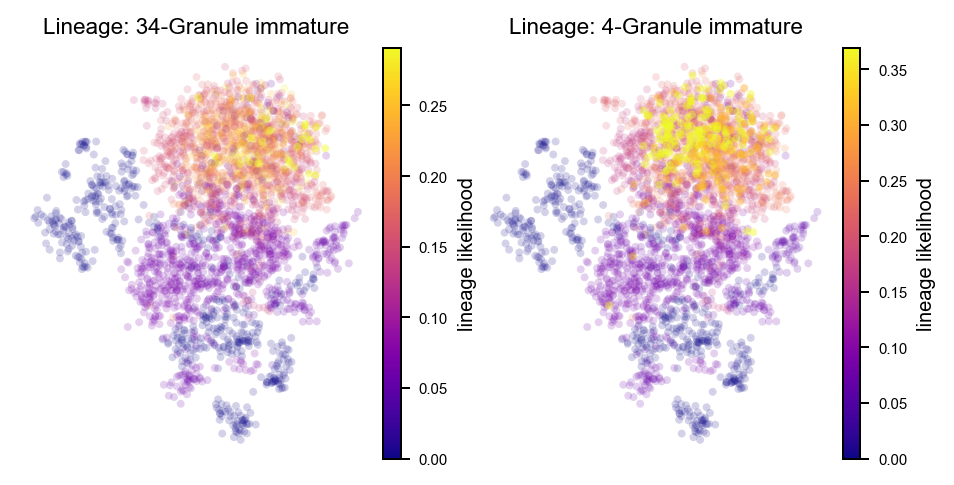

In [11]:
marker_lineages = list(v0.terminal_clusters)[:2]

fig, axs = VIA.core.plot_sc_lineage_probability(
    via_object=v0,
    embedding=stavia_embedding,
    marker_lineages=marker_lineages,
    dpi=90,
)
fig.set_size_inches(6, 3)
plt.show()


## StaVIA lineage path atlas view

location of 34 is at [0] and 0
setting vmin to 0.0


location of 4 is at [1] and 1
setting vmin to 0.0


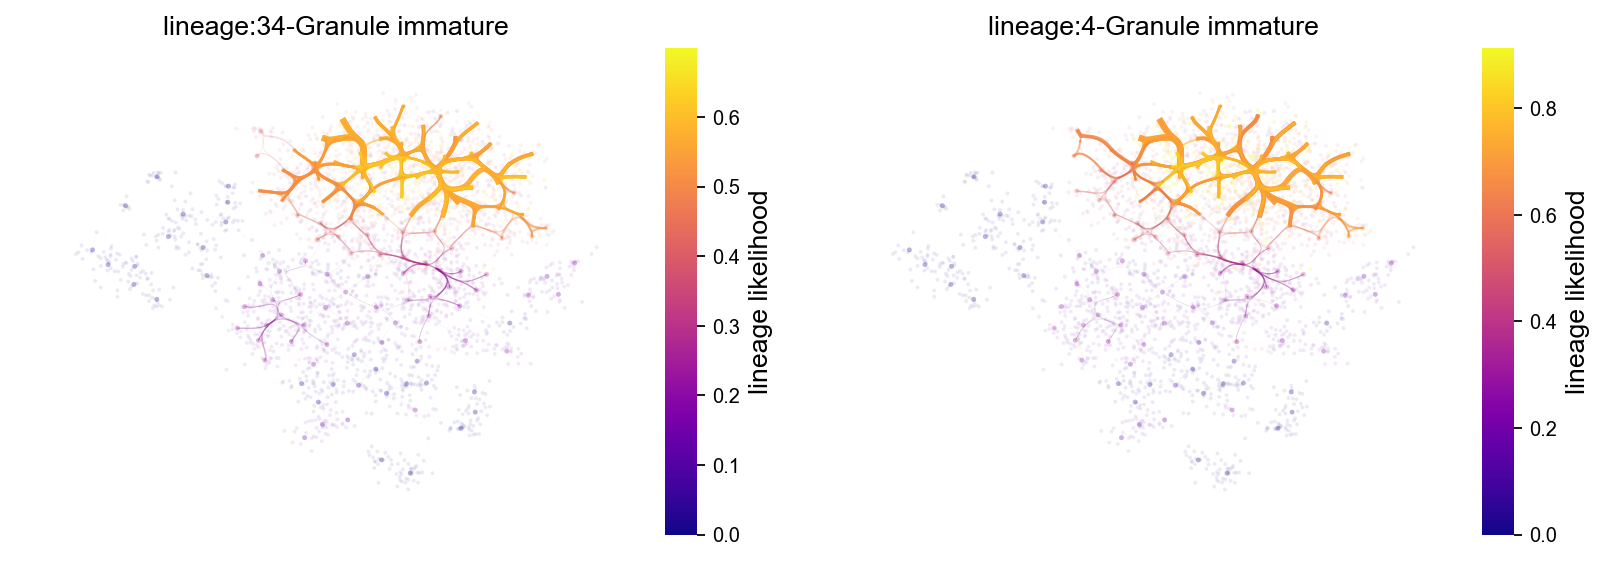

In [12]:
lineage_pathway = list(v0.terminal_clusters)[:2]

fig, axs = VIA.core.plot_atlas_view(
    via_object=v0,
    dpi=80,
    lineage_pathway=lineage_pathway,
    fontsize_title=12,
    fontsize_labels=12,
)
fig.set_size_inches(12, 4)
plt.show()

## StaVIA stream plots

We show stream plots colored by annotation and by pseudotime.

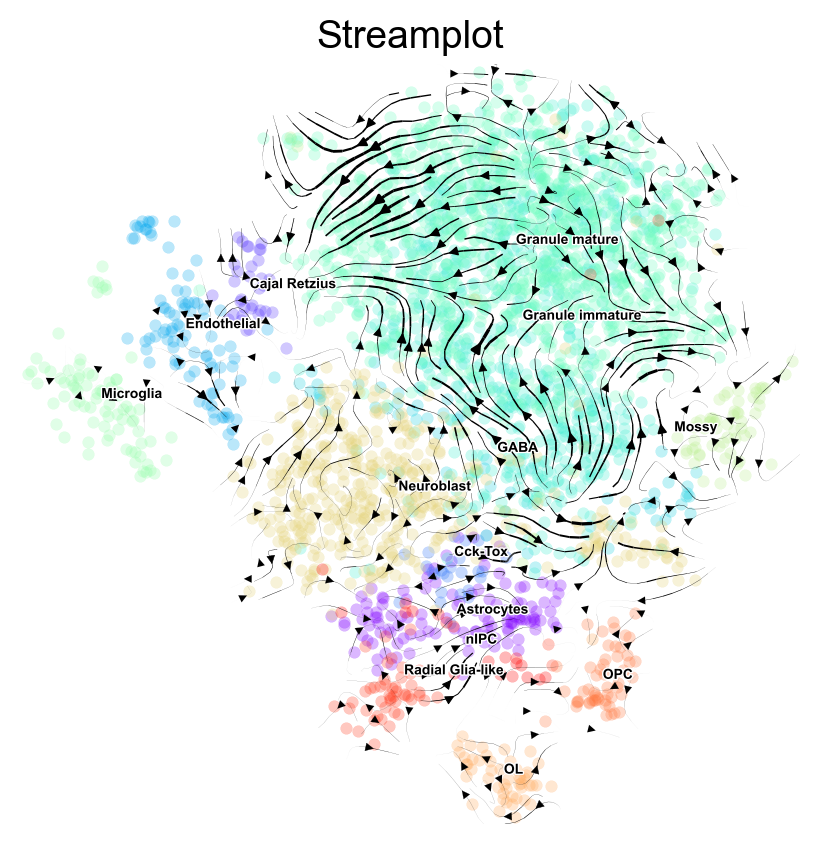

In [13]:
fig, ax = VIA.core.via_streamplot(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=100,
    density_grid=1.0,
    density_stream=2.5,
    scatter_size=18,
    scatter_alpha=0.28,
    linewidth=0.8,
)
fig.set_size_inches(5, 5)
plt.show()


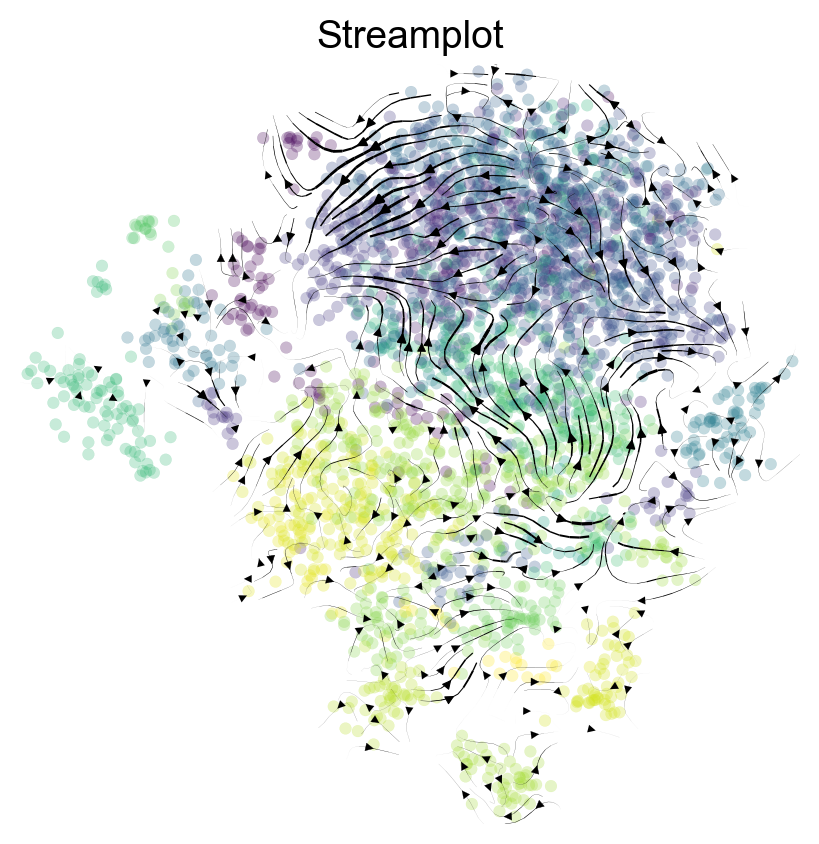

In [14]:
fig, ax = VIA.core.via_streamplot(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=100,
    density_grid=1.0,
    density_stream=2.5,
    scatter_size=18,
    scatter_alpha=0.28,
    linewidth=0.8,
    color_scheme="time",
    min_mass=1,
    cutoff_perc=5,
    marker_edgewidth=0.1,
    smooth_transition=1,
    smooth_grid=0.5,
)
fig.set_size_inches(5, 5)
plt.show()


## Gene / feature graph visualization

Selected genes are first smoothed with the fitted VIA graph in a MAGIC-like manner and then shown at the cluster level.

In [15]:
stavia_marker_genes = [
    gene
    for gene in ["Sox2", "Mki67", "Dcx", "Neurod1", "Stmn2", "Prox1"]
    if gene in adata.raw.var_names
]

df_gene = adata.raw[:, stavia_marker_genes].to_adata().to_df()
df_magic = v0.do_impute(
    df_gene,
    magic_steps=3,
    gene_list=stavia_marker_genes,
)

shape of transition matrix raised to power 3 (2930, 2930)


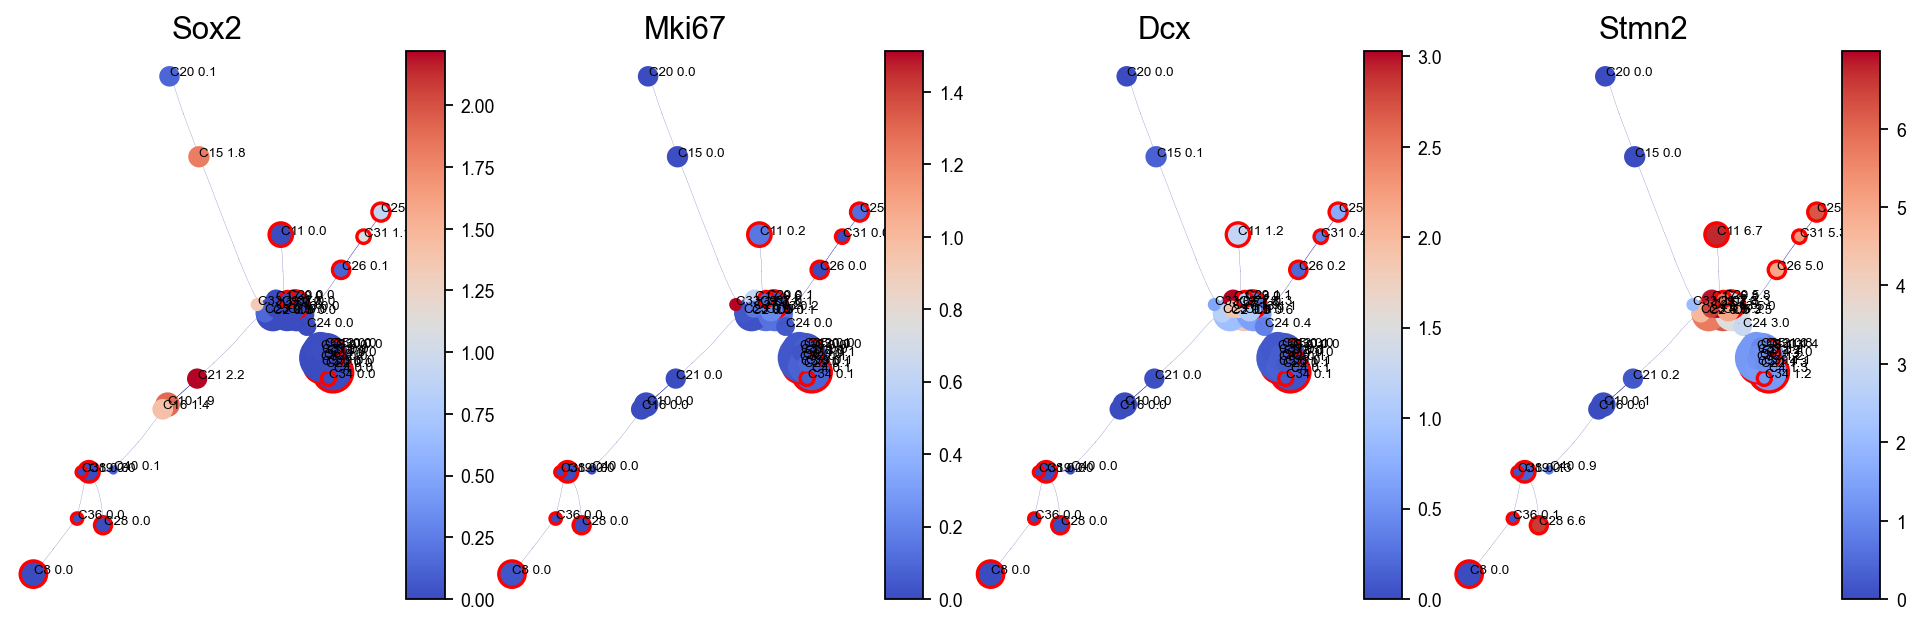

In [16]:
fig, axs = VIA.core.plot_viagraph(
    via_object=v0,
    type_data="gene",
    df_genes=df_magic.copy(),
    gene_list=stavia_marker_genes[:4],
    arrow_head=0.1,
)
fig.set_size_inches(12, 4)
plt.show()

## StaVIA lineage gene dynamics

Following the Gene Dynamics section in `t_via.ipynb`, VIA estimates gene dynamics along detected terminal lineages. We first show native VIA trend curves and heatmaps, then compare them with the general OmicVerse dynamic trend and dynamic heatmap workflow.

Area under curve Sox2 for branch Granule immature is 0.04555084777559561
Area under curve Sox2 for branch Granule immature is 0.045407271658158
Area under curve Sox2 for branch Granule mature is 0.01740516033550336
Area under curve Sox2 for branch Endothelial is 0.4365656783049289
Area under curve Sox2 for branch Granule immature is 0.03156509166196033
Area under curve Sox2 for branch Microglia is 0.4495056942016664
Area under curve Sox2 for branch Endothelial is 0.6048382824997743
Area under curve Sox2 for branch Mossy is 0.07180963739563352
Area under curve Sox2 for branch Granule immature is 0.04269178436885223
Area under curve Sox2 for branch Endothelial is 0.595204745491246
Area under curve Sox2 for branch GABA is 0.27454546430816434
Area under curve Sox2 for branch Cck-Tox is 0.03393808276100714
Area under curve Sox2 for branch Cajal Retzius is 0.3018231646426621
Area under curve Sox2 for branch Neuroblast is 0.03412303064142045
Area under curve Sox2 for branch Granule mature is 

Area under curve Mki67 for branch Granule immature is 0.0930850676340502
Area under curve Mki67 for branch Endothelial is 0.00040806315589284297
Area under curve Mki67 for branch GABA is 0.08492206396316215
Area under curve Mki67 for branch Cck-Tox is 0.07780565932132545
Area under curve Mki67 for branch Cajal Retzius is 0.003101291820012787
Area under curve Mki67 for branch Neuroblast is 0.07548092958536806
Area under curve Mki67 for branch Granule mature is 0.09545907843340447
Area under curve Mki67 for branch GABA is 0.0816514398903189
Area under curve Dcx for branch Granule immature is 0.5600034953433524
Area under curve Dcx for branch Granule immature is 0.5575764385598792
Area under curve Dcx for branch Granule mature is 0.585268527051407
Area under curve Dcx for branch Endothelial is 0.018151451059503495
Area under curve Dcx for branch Granule immature is 0.650718297123587
Area under curve Dcx for branch Microglia is 0.014293007292746351
Area under curve Dcx for branch Endotheli

Area under curve Stmn2 for branch Granule immature is 2.8383767039934504
Area under curve Stmn2 for branch Granule immature is 2.847803822475739
Area under curve Stmn2 for branch Granule mature is 2.911185556543988
Area under curve Stmn2 for branch Endothelial is 0.0966190501856051
Area under curve Stmn2 for branch Granule immature is 3.245992687762593
Area under curve Stmn2 for branch Microglia is 0.09391954819969517
Area under curve Stmn2 for branch Endothelial is 0.14685710778947692
Area under curve Stmn2 for branch Mossy is 2.8711828615219828
Area under curve Stmn2 for branch Granule immature is 2.875845353342913
Area under curve Stmn2 for branch Endothelial is 0.1499565135729379
Area under curve Stmn2 for branch GABA is 5.112751522344148
Area under curve Stmn2 for branch Cck-Tox is 3.1615089304845037
Area under curve Stmn2 for branch Cajal Retzius is 3.036941368001442


Area under curve Stmn2 for branch Neuroblast is 1.8466784259438742
Area under curve Stmn2 for branch Granule mature is 3.049142491873102
Area under curve Stmn2 for branch GABA is 4.118711675239748
Area under curve Prox1 for branch Granule immature is 2.3954569221844135
Area under curve Prox1 for branch Granule immature is 2.4353509185420212
Area under curve Prox1 for branch Granule mature is 2.2910714290599477
Area under curve Prox1 for branch Endothelial is 0.09097517269908757
Area under curve Prox1 for branch Granule immature is 1.686737503877866
Area under curve Prox1 for branch Microglia is 0.0917367946896335
Area under curve Prox1 for branch Endothelial is 0.09175331231000933
Area under curve Prox1 for branch Mossy is 1.5763457594481136
Area under curve Prox1 for branch Granule immature is 2.4625784415863725
Area under curve Prox1 for branch Endothelial is 0.09199137612619969
Area under curve Prox1 for branch GABA is 1.8498330745857954
Area under curve Prox1 for branch Cck-Tox is 

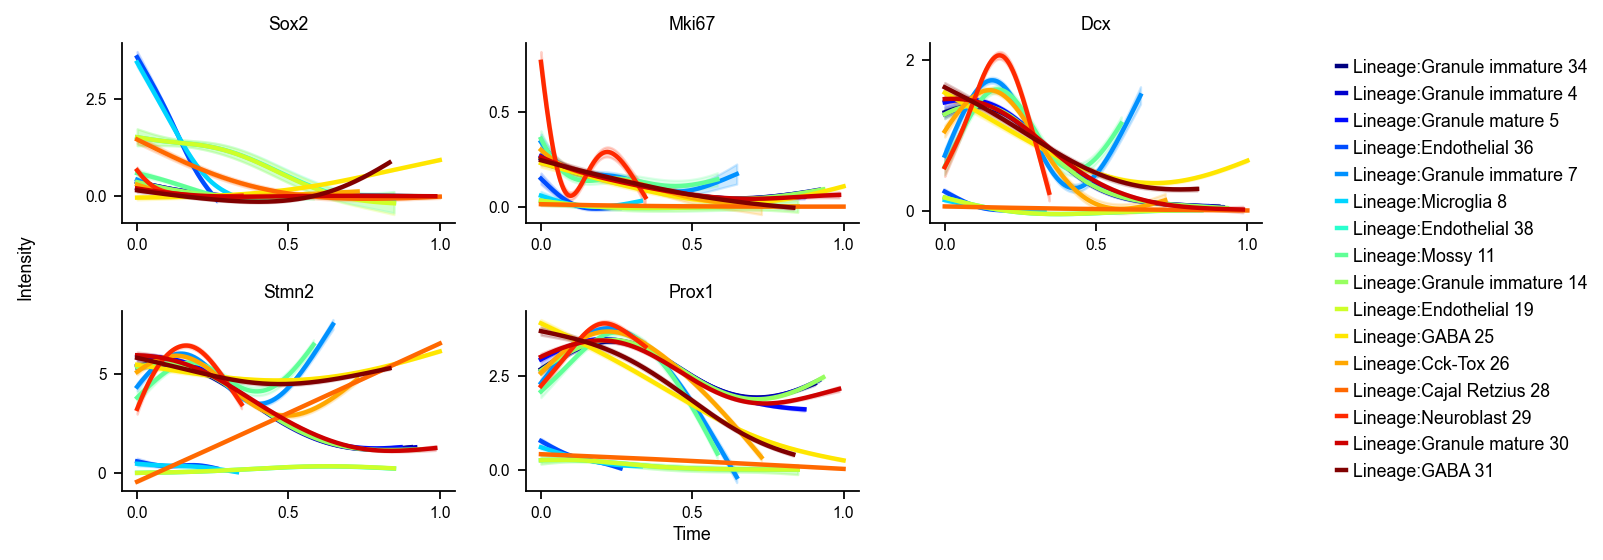

In [17]:
fig, axs = VIA.core.get_gene_expression(
    via_object=v0,
    gene_exp=df_magic[stavia_marker_genes],
    marker_genes=stavia_marker_genes,
    dpi=80,
    figsize=(10, 4),
    ncols=3,
    legend_loc="right",
)
plt.show()

## StaVIA lineage gene dynamics

VIA estimates gene dynamics along detected terminal lineages. We first show native VIA trend curves and heatmaps, then compare them with the general OmicVerse dynamic trend and dynamic heatmap workflow.

branches [34, 4]


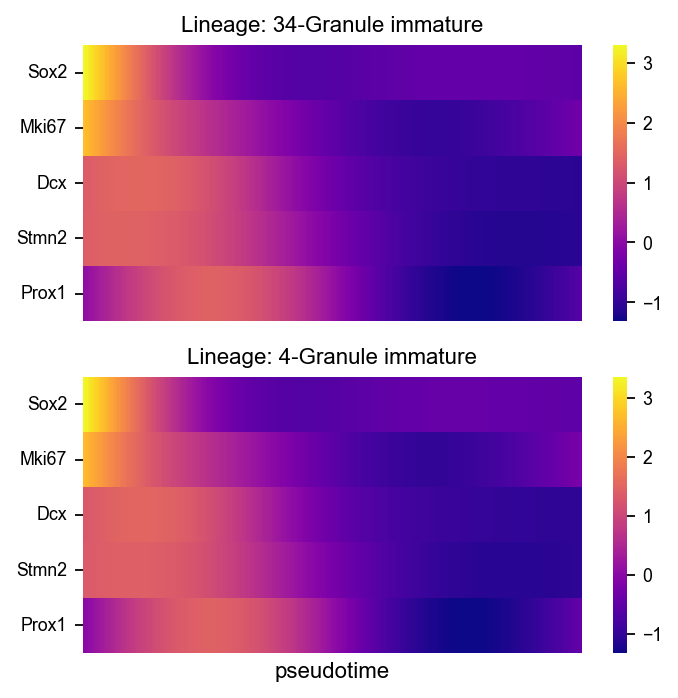

In [18]:
marker_lineages = list(v0.terminal_clusters)[:2]

fig, axs = VIA.core.plot_gene_trend_heatmaps(
    via_object=v0,
    df_gene_exp=df_magic[stavia_marker_genes],
    cmap="plasma",
    marker_lineages=marker_lineages,
)
fig.set_size_inches(5, max(3, 2.5 * len(marker_lineages)))
plt.show()